### Feature Extractor 시각화.

In [73]:
import sys 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec 
from matplotlib.ticker import FuncFormatter
from datetime import date 
from pathlib import Path 

In [3]:
from mps.sys import cfg, MPF_STYLE
from mps.sys.dataio import LocalParquetStore, HistoricalDataLoader
from mps.pipline.models.numerical.extractor import FeatureExtractor

In [35]:
# start_date: date = date(int(cfg.run.start_date[:4]), int(cfg.run.start_date[4:6]), int(cfg.run.start_date[6:]))
# end_date: date = date(int(cfg.run.end_date[:4]), int(cfg.run.end_date[4:6]), int(cfg.run.end_date[6:]))
start_date: date = date(2023, 1, 1)
end_date: date = date(2023, 3, 31)
ticker = cfg.run.tickers[0]
cfg.run.tickers[0], start_date, end_date

('005930', datetime.date(2023, 1, 1), datetime.date(2023, 3, 31))

In [36]:
store = LocalParquetStore()
loader = HistoricalDataLoader(store)
msg, bars = loader.load(ticker, start_date, end_date)
print(f"출력 메시지: {msg}, 로드된 봉 수: {len(bars):,}")

sys/dataio/_store.py:[32] = base_dir: [None], self._base_dir: [/home/freeman/projects/mps/data/store]
ys/dataio/_loader.py:[30] = store: [<mps.sys.dataio._store.LocalParquetStore object at 0x7f438bd1fd10>], self._store: [<mps.sys.dataio._store.LocalParquetStore object at 0x7f438bd1fd10>]
ys/dataio/_loader.py:[55] = 처리 일시: 2023-01-01 00:00:00+09:00 ~ 2023-03-31 23:59:59.999999+09:00
sys/dataio/_store.py:[40] = store filepath: [/home/freeman/projects/mps/data/store/005930/minute_bars.parquet]
sys/dataio/_store.py:[61] = 불러올 대상 날짜: [2023-01-01 00:00:00+09:00 ~ 2023-03-31 23:59:59.999999+09:00], Mask: [[ True  True  True ...  True  True  True]]
sys/dataio/_store.py:[62] = 불러온 데이터프레임 크기: [(24180, 7)]
sys/dataio/_store.py:[77] = 리턴할 데이터 크기: [24,180]
출력 메시지: STORE, 로드된 봉 수: 24,180


In [37]:
extractor = FeatureExtractor()
raw = extractor.extract(bars)

merical/extractor.py:[59] = 원본 봉 갯 수: 24180, 변경된 데이터프레임 사이즈: (24180, 5), ndarray shape: (24180, 14)


In [38]:
timestamps = [bar.timestamp for bar in bars]
df = pd.DataFrame(raw, columns=extractor.FEATURE_NAMES, index=timestamps)
print(f"일시: {timestamps[0]} ~ {timestamps[-1]}")
df.head()

일시: 2023-01-02 09:00:00+09:00 ~ 2023-03-31 15:29:00+09:00


,rsi_14,macd,macd_signal,macd_diff,bb_upper,bb_mid,bb_lower,bb_pband,obv,atr_14,volume_ratio,ret_1,ret_5,ret_20
2023-01-02 09:00:00+09:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,88463.0,0.0,0.0,0.000000,0.0,0.0
2023-01-02 09:01:00+09:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6963.0,0.0,0.0,-0.000787,0.0,0.0
2023-01-02 09:02:00+09:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53286.0,0.0,0.0,0.000573,0.0,0.0
2023-01-02 09:03:00+09:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,132286.0,0.0,0.0,0.000716,0.0,0.0
2023-01-02 09:04:00+09:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96452.0,0.0,0.0,-0.001485,0.0,0.0


In [39]:
price_df = pd.DataFrame({
    "open": [bar.open for bar in bars],
    "high": [bar.high for bar in bars],
    "low": [bar.low for bar in bars],
    "close": [bar.close for bar in bars],
    "volume": [bar.volume for bar in bars]
}, index=timestamps)
price_df.head()

,open,high,low,close,volume
2023-01-02 09:00:00+09:00,55500.0,55881.0,55488.0,55880.0,88463
2023-01-02 09:01:00+09:00,55880.0,55881.0,55830.0,55836.0,81500
2023-01-02 09:02:00+09:00,55836.0,55893.0,55812.0,55868.0,46323
2023-01-02 09:03:00+09:00,55868.0,55933.0,55857.0,55908.0,79000
2023-01-02 09:04:00+09:00,55908.0,55938.0,55804.0,55825.0,35834


In [40]:
# 워밍업 구간 제거 (첫 LOOKBACK 봉은 NaN → 0 채움 구간)
df = df.iloc[cfg.sys.lookback_minutes:]
price_df = price_df.iloc[cfg.sys.lookback_minutes:]

print(f"분석 대상 봉 수: {len(df):,} ({df.index[0]} ~ {df.index[-1]})")
df.head()

분석 대상 봉 수: 24,060 (2023-01-02 11:00:00+09:00 ~ 2023-03-31 15:29:00+09:00)


,rsi_14,macd,macd_signal,macd_diff,bb_upper,bb_mid,bb_lower,bb_pband,obv,atr_14,volume_ratio,ret_1,ret_5,ret_20
2023-01-02 11:00:00+09:00,35.088551,-68.510017,-75.216049,6.706026,55723.250000,55587.601562,55451.953125,0.236083,-69692.0,66.704041,0.997872,-0.000774,0.000451,-0.002175
2023-01-02 11:01:00+09:00,36.295952,-65.819832,-73.336807,7.516970,55708.648438,55579.148438,55449.652344,0.283201,-44137.0,64.296608,1.392977,0.000126,0.000396,-0.003035
2023-01-02 11:02:00+09:00,37.895443,-62.244106,-71.118263,8.874158,55694.738281,55571.898438,55449.062500,0.337591,-1046.0,61.775421,2.187577,0.000162,0.000541,-0.002604
2023-01-02 11:03:00+09:00,47.111538,-54.106495,-67.715912,13.609416,55672.351562,55566.000000,55459.648438,0.612833,43139.0,63.291462,2.145929,0.001044,0.000378,-0.002118
2023-01-02 11:04:00+09:00,51.763378,-44.322254,-63.037178,18.714926,55663.386719,55563.851562,55464.312500,0.807171,80724.0,64.484932,1.748929,0.000630,0.001188,-0.000772


### 가격 + 볼린저밴드

In [41]:
price_df.head()

,open,high,low,close,volume
2023-01-02 11:00:00+09:00,55559.0,55573.0,55494.0,55516.0,18309
2023-01-02 11:01:00+09:00,55516.0,55535.0,55502.0,55523.0,25555
2023-01-02 11:02:00+09:00,55523.0,55548.0,55519.0,55532.0,43091
2023-01-02 11:03:00+09:00,55532.0,55593.0,55510.0,55590.0,44185
2023-01-02 11:04:00+09:00,55590.0,55647.0,55567.0,55625.0,37585


In [42]:
df.head()

,rsi_14,macd,macd_signal,macd_diff,bb_upper,bb_mid,bb_lower,bb_pband,obv,atr_14,volume_ratio,ret_1,ret_5,ret_20
2023-01-02 11:00:00+09:00,35.088551,-68.510017,-75.216049,6.706026,55723.250000,55587.601562,55451.953125,0.236083,-69692.0,66.704041,0.997872,-0.000774,0.000451,-0.002175
2023-01-02 11:01:00+09:00,36.295952,-65.819832,-73.336807,7.516970,55708.648438,55579.148438,55449.652344,0.283201,-44137.0,64.296608,1.392977,0.000126,0.000396,-0.003035
2023-01-02 11:02:00+09:00,37.895443,-62.244106,-71.118263,8.874158,55694.738281,55571.898438,55449.062500,0.337591,-1046.0,61.775421,2.187577,0.000162,0.000541,-0.002604
2023-01-02 11:03:00+09:00,47.111538,-54.106495,-67.715912,13.609416,55672.351562,55566.000000,55459.648438,0.612833,43139.0,63.291462,2.145929,0.001044,0.000378,-0.002118
2023-01-02 11:04:00+09:00,51.763378,-44.322254,-63.037178,18.714926,55663.386719,55563.851562,55464.312500,0.807171,80724.0,64.484932,1.748929,0.000630,0.001188,-0.000772


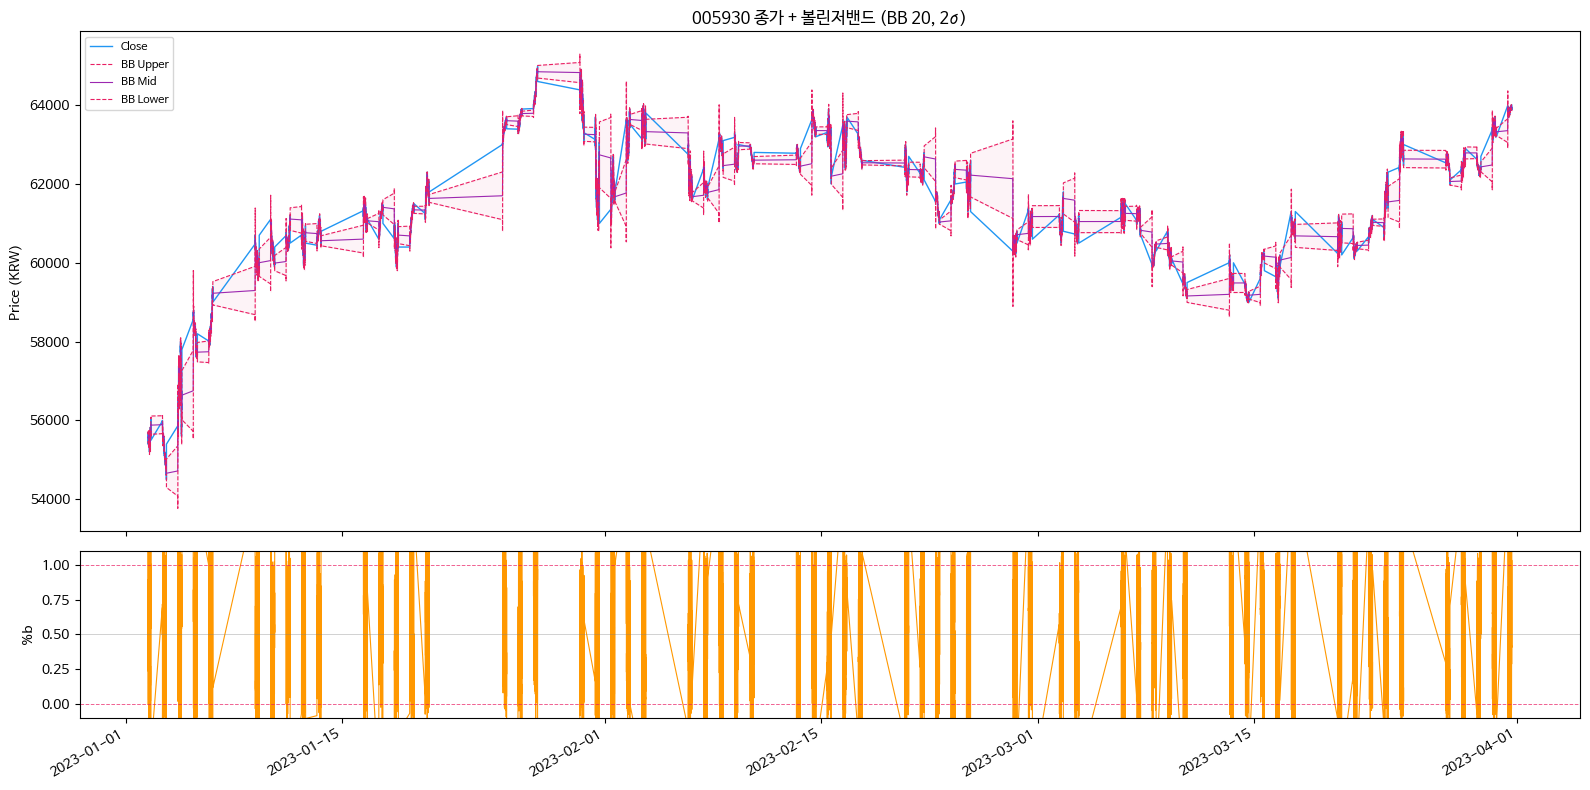

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8),
                         gridspec_kw={"height_ratios": [3, 1]},
                         sharex=True)
ax1, ax2 = axes 

# ── 가격 + BB ────────────────────────
ax1.plot(price_df.index, price_df["close"], color="#2196f3", lw=1.0, label="Close")
ax1.plot(df.index,       df["bb_upper"],    color="#e91e63", lw=0.8, ls="--", label="BB Upper")
ax1.plot(df.index,       df["bb_mid"],      color="#9c27b0", lw=0.8, ls="-", label="BB Mid")
ax1.plot(df.index,       df["bb_lower"],    color="#e91e63", lw=0.8, ls="--", label="BB Lower")
ax1.fill_between(df.index, df["bb_upper"], df["bb_lower"], alpha=0.05, color="#e91e63")
ax1.set_ylabel("Price (KRW)")
ax1.legend(loc="upper left", fontsize=8)
ax1.set_title(f"{ticker} 종가 + 볼린저밴드 (BB 20, 2σ)")

ax2.plot(df.index, df["bb_pband"], color="#ff9800", lw=0.8)
ax2.axhline(1.0, color="#e91e63", ls="--", lw=0.7, alpha=0.7)
ax2.axhline(0.0, color="#e91e63", ls="--", lw=0.7, alpha=0.7)
ax2.axhline(0.5, color="gray", ls="-", lw=0.5, alpha=0.5)
ax2.set_ylabel("%b")
ax2.set_ylim(-0.1, 1.1)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### RSI

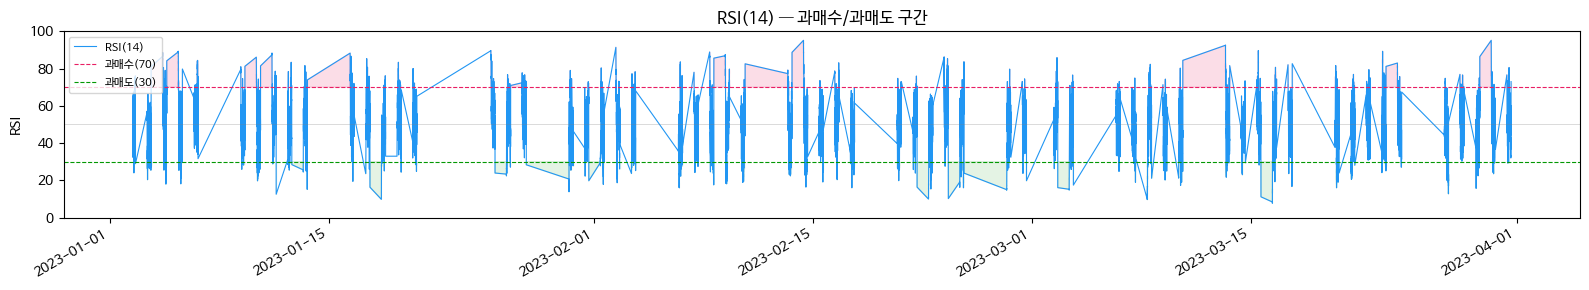

In [58]:
fig, ax = plt.subplots(figsize=(16, 3))

ax.plot(df.index, df["rsi_14"], color="#2196f3", lw=0.8, label="RSI(14)")
ax.axhline(70, color="#e91e63", ls="--", lw=0.8, label="과매수(70)")
ax.axhline(50, color="gray", ls="-", lw=0.5, alpha=0.4)
ax.axhline(30, color="#039803", ls="--", lw=0.8, label="과매도(30)")
ax.fill_between(df.index, df["rsi_14"], 70, 
                where=(df["rsi_14"] >= 70).tolist(), alpha=0.15, color="#e91e63")
ax.fill_between(df.index, df["rsi_14"], 30,
                where=(df["rsi_14"] <= 30).tolist(), alpha=0.15, color="#4caf50")

ax.set_ylabel("RSI")
ax.set_ylim(0, 100)
ax.set_title("RSI(14) ─ 과매수/과매도 구간")

ax.legend(fontsize=8)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### MACD

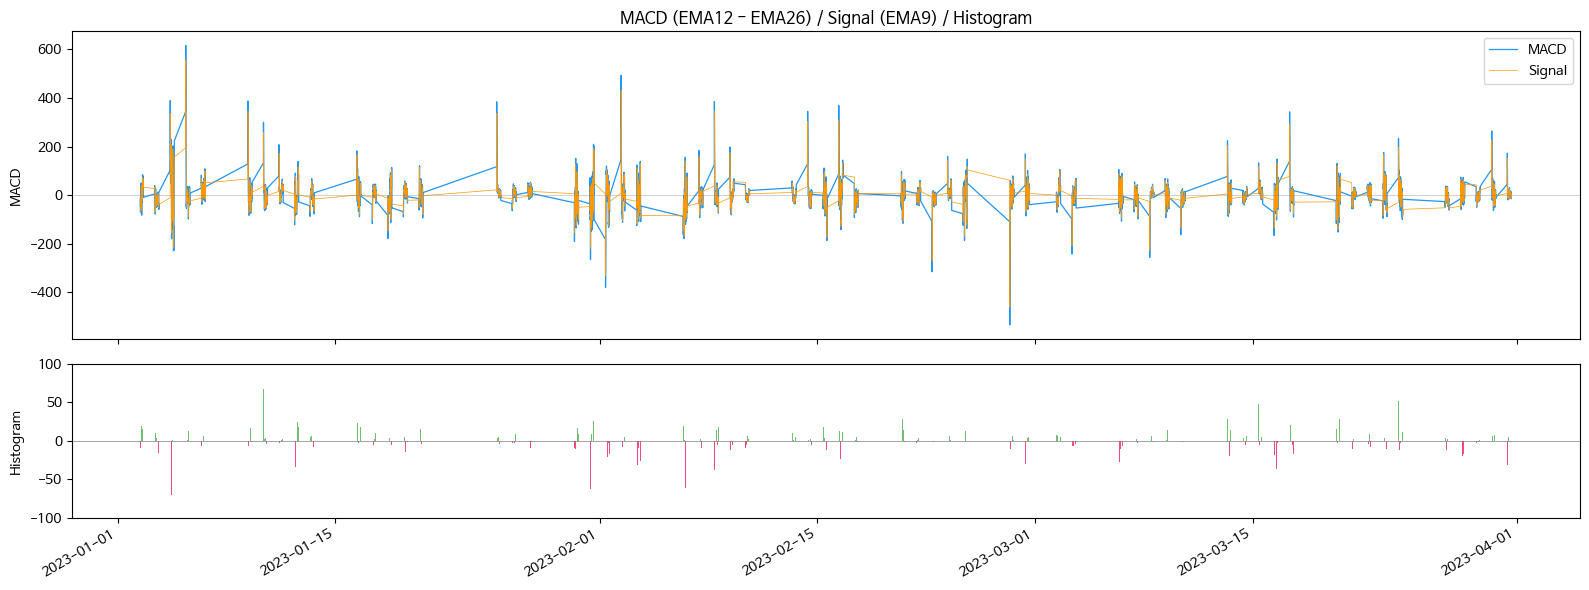

In [67]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6),
                               gridspec_kw={"height_ratios": [2,1]},
                               sharex=True)

# ── MACD 선 + 시그널 선 ──────────────────────────
ax1.plot(df.index, df["macd"], color="#2196f3", lw=0.9, label="MACD")
ax1.plot(df.index, df["macd_signal"], color="#ff9800", lw=0.5, label="Signal")
ax1.axhline(0, color="gray", lw=0.5, alpha=0.5)
ax1.set_ylabel("MACD")
ax1.set_title("MACD (EMA12 - EMA26) / Signal (EMA9) / Histogram")
ax1.legend()

# ── 히스토그램 ───────────────────────────────
colors = ["#4caf50" if value >= 0 else "#e91e63" for value in df["macd_diff"]]
ax2.bar(df.index, df["macd_diff"], color=colors, width=0.0005, alpha=0.8)
ax2.axhline(0, color="gray", lw=0.5)
ax2.set_ylabel("Histogram")
ax2.set_ylim(-100, 100)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### ATR(14) ─ 변동성

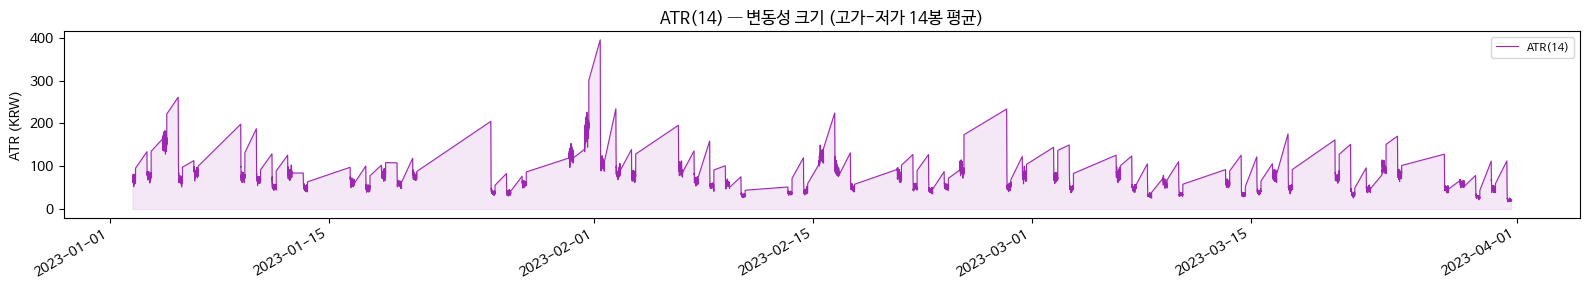

In [69]:
fig, ax = plt.subplots(figsize=(16, 3))

ax.plot(df.index, df["atr_14"], color="#9c27b0", lw=0.8, label="ATR(14)")
ax.fill_between(df.index, df["atr_14"], alpha=0.1, color="#9c27b0")
ax.set_ylabel("ATR (KRW)")
ax.set_title("ATR(14) ─ 변동성 크기 (고가-저가 14봉 평균)")
ax.legend(fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 거래량 ─ OBV / VolumeRatio

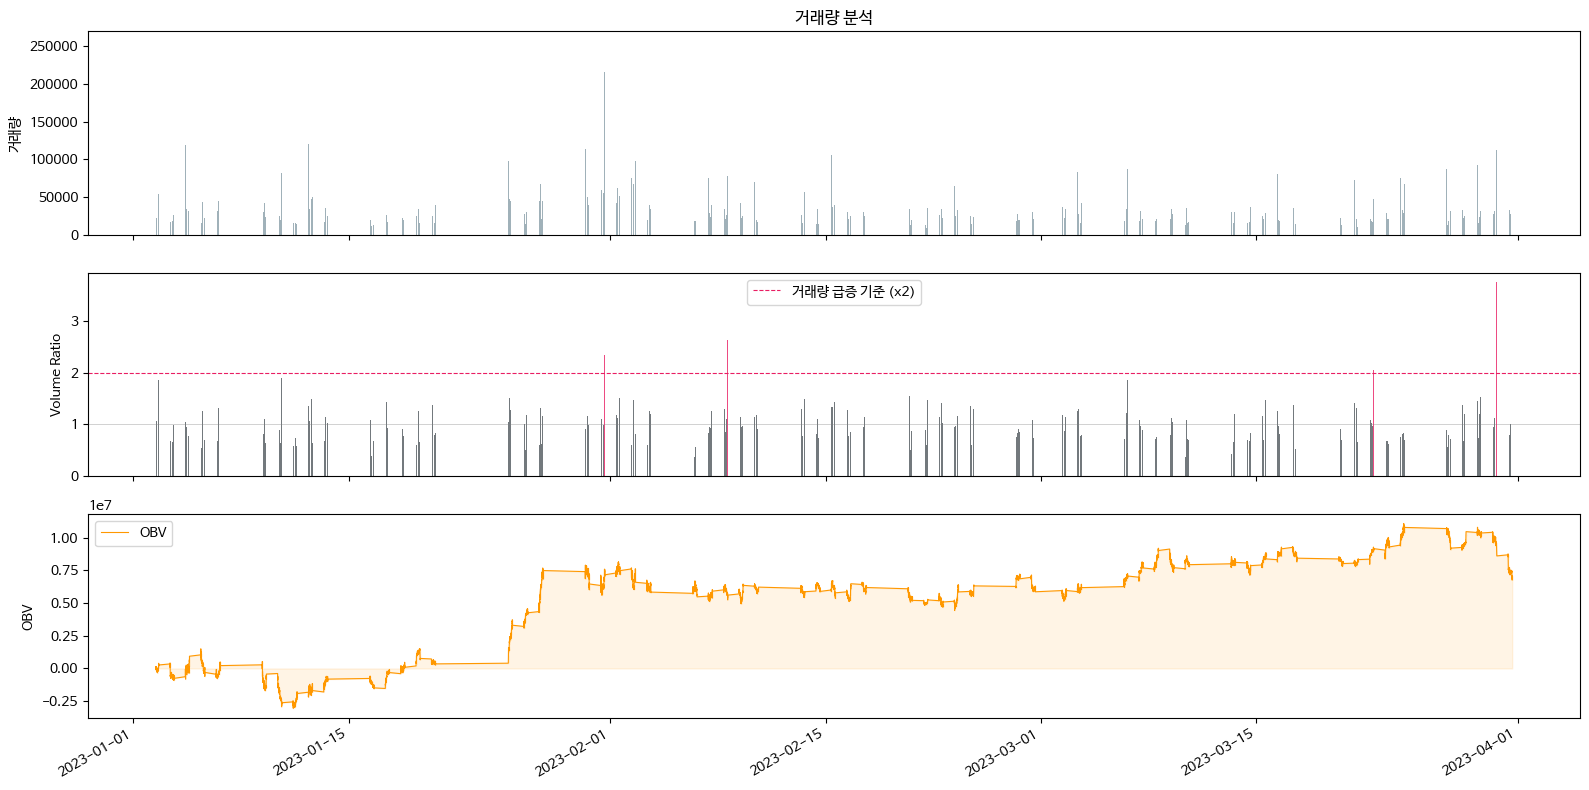

In [72]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 8), 
                                    gridspec_kw={"height_ratios": [1, 1, 1]},
                                    sharex=True)

ax1.bar(price_df.index, price_df["volume"], color="#78909c", width=0.0005, alpha=0.7)
ax1.set_ylabel("거래량")
ax1.set_title("거래량 분석")

vr = df["volume_ratio"]
colors = ["#e91e63" if value >= 2.0 else "#50585d" for value in vr]
ax2.bar(df.index, vr, color=colors, width=0.0005, alpha=0.8)
ax2.axhline(2.0, color="#e91e63", ls="--", lw=0.8, label="거래량 급증 기준 (x2)")
ax2.axhline(1.0, color="gray", ls="-", lw=0.5, alpha=0.5)
ax2.set_ylabel("Volume Ratio")
ax2.legend()

ax3.plot(df.index, df["obv"], color="#ff9800", lw=0.8, label="OBV")
ax3.fill_between(df.index, df["obv"], alpha=0.1, color="#ff9800")
ax3.set_ylabel("OBV")
ax3.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 수익률 ─ ret_1 · ret_5 · ret_20

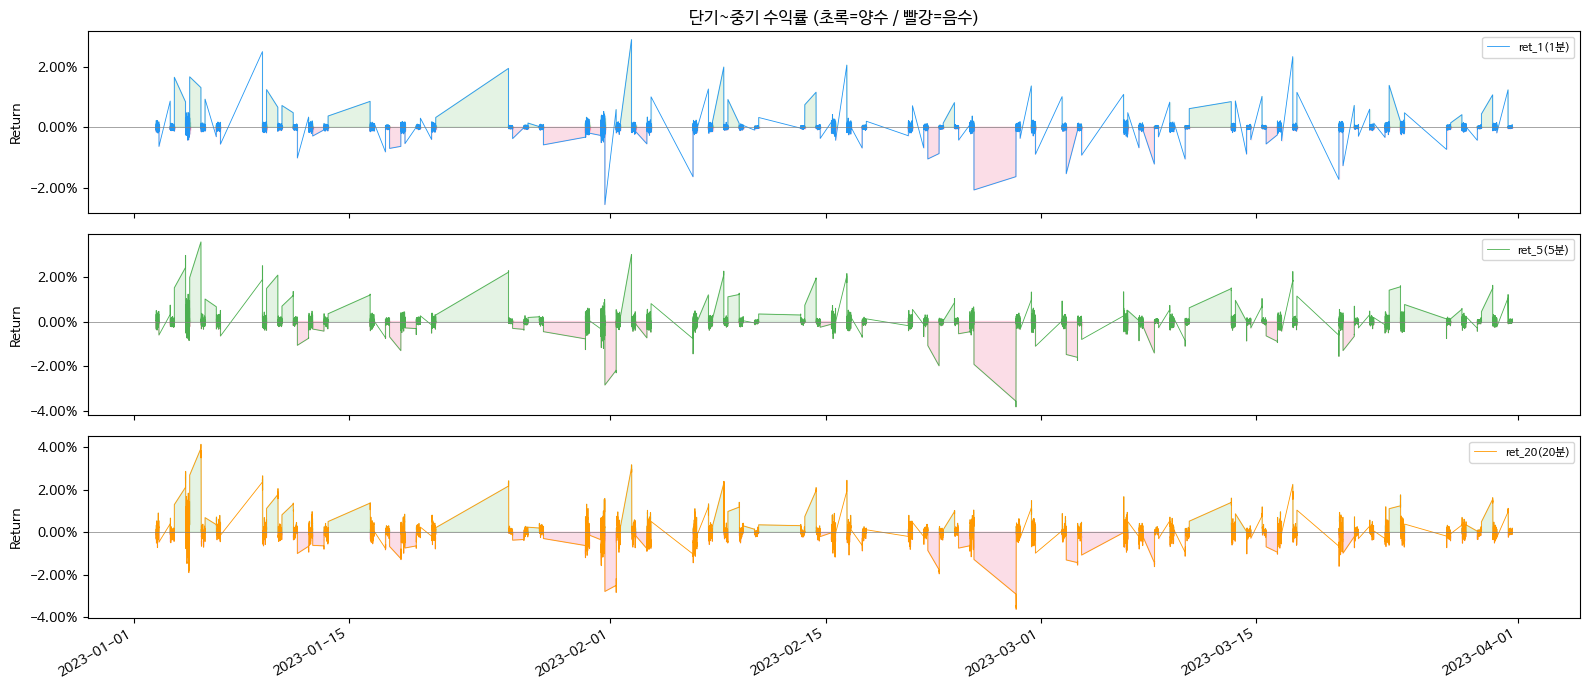

In [75]:
fig, axes = plt.subplots(3, 1, figsize=(16, 7), sharex=True)

for ax, column, color, label in zip(
    axes, 
    ["ret_1", "ret_5", "ret_20"],
    ["#2196f3", "#4caf50", "#ff9800"],
    ["ret_1(1분)", "ret_5(5분)", "ret_20(20분)"],
):
    series = df[column]
    ax.plot(df.index, series, color=color, lw=0.6, label=label)
    ax.fill_between(df.index, series, 0, 
                    where=(series >= 0), alpha=0.15, color="#4caf50")
    ax.fill_between(df.index, series, 0,
                    where=(series < 0), alpha=0.15, color="#e91e63")
    ax.axhline(0, color="gray", lw=0.5)
    ax.set_ylabel("Return")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}"))
    ax.legend(fontsize=8)

axes[0].set_title("단기~중기 수익률 (초록=양수 / 빨강=음수)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 전체 대시보드 요약

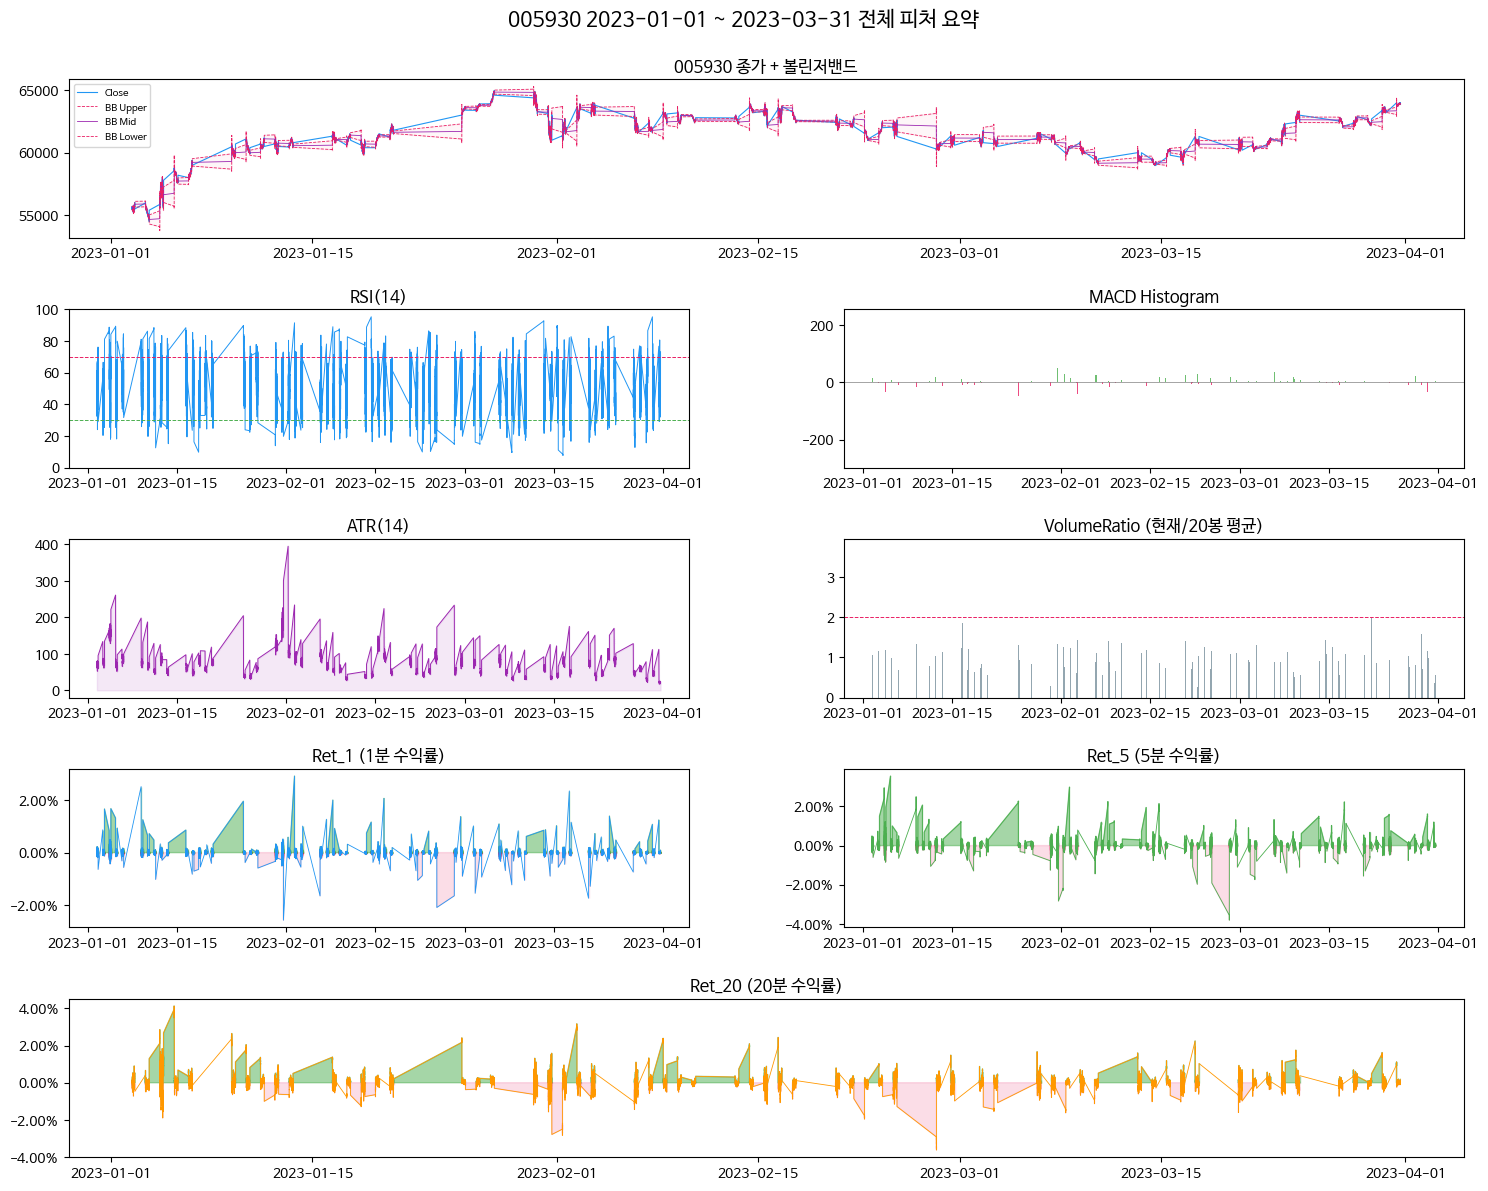

In [98]:
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.25)

# 종가 + BB
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(price_df.index, price_df["close"], color="#2196f3", lw=0.8, label="Close")
ax1.plot(df.index, df["bb_upper"], color="#e91e63", lw=0.6, ls="--")
ax1.plot(df.index, df["bb_mid"], color="#9c27b0", lw=0.6)
ax1.plot(df.index, df["bb_lower"], color="#e91e63", lw=0.6, ls="--")
ax1.fill_between(df.index, df["bb_upper"], df["bb_lower"], alpha=0.04, color="#e91e63")
ax1.set_title(f"{ticker} 종가 + 볼린저밴드")
ax1.legend(["Close", "BB Upper", "BB Mid", "BB Lower"], fontsize=7, loc="upper left")

# RSI
ax21 = fig.add_subplot(gs[1, 0])
ax21.plot(df.index, df["rsi_14"], color="#2196f3", lw=0.7)
ax21.axhline(70, color="#e91e63", ls="--", lw=0.7)
ax21.axhline(30, color="#4caf50", ls="--", lw=0.7)
ax21.set_ylim(0, 100)
ax21.set_title("RSI(14)")
# MACD Histogram
ax22 = fig.add_subplot(gs[1, 1])
colors_h = ["#4caf50" if value >= 0 else "#e91e63" for value in df["macd_diff"]]
ax22.bar(df.index, df["macd_diff"], color=colors_h, width=0.0005, alpha=0.8)
ax22.axhline(0, color="gray", lw=0.5)
ax22.set_title("MACD Histogram")

# ATR
ax31 = fig.add_subplot(gs[2, 0])
ax31.plot(df.index, df["atr_14"], color="#9c27b0", lw=0.7)
ax31.fill_between(df.index, df["atr_14"], alpha=0.1, color="#9c27b0")
ax31.set_title("ATR(14)")
# VolumeRatio
ax32 = fig.add_subplot(gs[2, 1])
colors_v = ["#e91e63" if value >= 2 else "#78909c" for value in df["volume_ratio"]]
ax32.bar(df.index, df["volume_ratio"], color=colors_v, width=0.0005, alpha=0.8)
ax32.axhline(2.0, color="#e91e63", ls="--", lw=0.7)
ax32.set_title("VolumeRatio (현재/20봉 평균)")

# Ret_1
ax41 = fig.add_subplot(gs[3, 0])
ret = df["ret_1"]
ax41.plot(df.index, ret, color="#2196f3", lw=0.6)
ax41.fill_between(df.index, ret, 0, where=(ret >= 0).tolist(), alpha=0.5, color="#4caf50")
ax41.fill_between(df.index, ret, 0, where=(ret < 0).tolist(), alpha=0.15, color="#e91e63")
ax41.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}"))
ax41.set_title("Ret_1 (1분 수익률)")
# Ret_5
ax42 = fig.add_subplot(gs[3, 1])
ret = df["ret_5"]
ax42.plot(df.index, ret, color="#4CAF50", lw=0.6)
ax42.fill_between(df.index, ret, 0, where=(ret >= 0).tolist(), alpha=0.5, color="#4caf50")
ax42.fill_between(df.index, ret, 0, where=(ret < 0).tolist(), alpha=0.15, color="#e91e63")
ax42.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}"))
ax42.set_title("Ret_5 (5분 수익률)")

# Ret_20
ax50 = fig.add_subplot(gs[4, :])
ret = df["ret_20"]
ax50.plot(df.index, ret, color="#FF9800", lw=0.6)
ax50.fill_between(df.index, ret, 0, where=(ret >= 0).tolist(), alpha=0.5, color="#4caf50")
ax50.fill_between(df.index, ret, 0, where=(ret < 0).tolist(), alpha=0.15, color="#e91e63")
ax50.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.2%}"))
ax50.set_title("Ret_20 (20분 수익률)")

fig.suptitle(f"{ticker} {start_date} ~ {end_date} 전체 피처 요약",
             fontsize=15, fontweight="bold", y=0.93)
plt.show()